In [1]:
!pip install openpyxl joblib

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [3]:
print(os.listdir("/content"))

['.config', 'sample_data']


In [4]:
train = pd.read_excel("/content/train.xlsx")
test = pd.read_excel("/content/test.xlsx")

print("Train shape:", train.shape)
print("Test shape:", test.shape)

train.head()

FileNotFoundError: [Errno 2] No such file or directory: '/content/train.xlsx'

In [5]:
from google.colab import files
uploaded = files.upload()

Saving test.xlsx to test.xlsx
Saving train.xlsx to train.xlsx


In [6]:
print(os.listdir("/content"))

['.config', 'test.xlsx', 'train.xlsx', 'sample_data']


In [7]:
train = pd.read_excel("/content/train.xlsx")
test = pd.read_excel("/content/test.xlsx")

print("Train shape:", train.shape)
print("Test shape:", test.shape)

train.head()

Train shape: (20631, 26)
Test shape: (13096, 26)


,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Fan inlet temperature,LPC outlet temperature,HPC outlet temperature,LPT outlet temperature,Fan inlet Pressure,...,Ratio of fuel flow to Ps30,Corrected fan speed,Corrected core speed,Bypass Ratio,Burner fuel-air ratio,Bleed Enthalpy,Required fan speed,Required fan conversion speed,High-pressure turbines Cool air flow,Low-pressure turbines Cool air flow
0,1,1,-0.0007,-0.0004,100,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100,39.06,23.4190
1,1,2,0.0019,-0.0003,100,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100,39.00,23.4236
2,1,3,-0.0043,0.0003,100,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100,38.95,23.3442
3,1,4,0.0007,0.0000,100,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100,38.88,23.3739
4,1,5,-0.0019,-0.0002,100,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100,38.90,23.4044


In [8]:
train = pd.read_excel("/content/train_FD001.xlsx")
test = pd.read_excel("/content/test_FD001.xlsx")

FileNotFoundError: [Errno 2] No such file or directory: '/content/train_FD001.xlsx'

In [9]:
column_names = [
    "unit_number",
    "time_cycle",
    "setting_1",
    "setting_2",
    "setting_3",
    "sensor_1",
    "sensor_2",
    "sensor_3",
    "sensor_4",
    "sensor_5",
    "sensor_6",
    "sensor_7",
    "sensor_8",
    "sensor_9",
    "sensor_10",
    "sensor_11",
    "sensor_12",
    "sensor_13",
    "sensor_14",
    "sensor_15",
    "sensor_16",
    "sensor_17",
    "sensor_18",
    "sensor_19",
    "sensor_20",
    "sensor_21"
]

if train.shape[1] == 26:
    train.columns = column_names

if test.shape[1] == 26:
    test.columns = column_names

print(train.columns)
train.head()

Index(['unit_number', 'time_cycle', 'setting_1', 'setting_2', 'setting_3',
       'sensor_1', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_5', 'sensor_6',
       'sensor_7', 'sensor_8', 'sensor_9', 'sensor_10', 'sensor_11',
       'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_16',
       'sensor_17', 'sensor_18', 'sensor_19', 'sensor_20', 'sensor_21'],
      dtype='object')


,unit_number,time_cycle,setting_1,setting_2,setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100,39.06,23.4190
1,1,2,0.0019,-0.0003,100,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100,39.00,23.4236
2,1,3,-0.0043,0.0003,100,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100,38.95,23.3442
3,1,4,0.0007,0.0000,100,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100,38.88,23.3739
4,1,5,-0.0019,-0.0002,100,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100,38.90,23.4044


In [10]:
print("Train eksik veri:")
print(train.isnull().sum())

print("Test eksik veri:")
print(test.isnull().sum())

Train eksik veri:
unit_number    0
time_cycle     0
setting_1      0
setting_2      0
setting_3      0
sensor_1       0
sensor_2       0
sensor_3       0
sensor_4       0
sensor_5       0
sensor_6       0
sensor_7       0
sensor_8       0
sensor_9       0
sensor_10      0
sensor_11      0
sensor_12      0
sensor_13      0
sensor_14      0
sensor_15      0
sensor_16      0
sensor_17      0
sensor_18      0
sensor_19      0
sensor_20      0
sensor_21      0
dtype: int64
Test eksik veri:
unit_number    0
time_cycle     0
setting_1      0
setting_2      0
setting_3      0
sensor_1       0
sensor_2       0
sensor_3       0
sensor_4       0
sensor_5       0
sensor_6       0
sensor_7       0
sensor_8       0
sensor_9       0
sensor_10      0
sensor_11      0
sensor_12      0
sensor_13      0
sensor_14      0
sensor_15      0
sensor_16      0
sensor_17      0
sensor_18      0
sensor_19      0
sensor_20      0
sensor_21      0
dtype: int64


In [11]:
max_cycle = train.groupby("unit_number")["time_cycle"].max().reset_index()
max_cycle.columns = ["unit_number", "max_cycle"]

train = train.merge(max_cycle, on="unit_number", how="left")
train["RUL"] = train["max_cycle"] - train["time_cycle"]

train = train.drop(columns=["max_cycle"])

train[["unit_number", "time_cycle", "RUL"]].head(15)

,unit_number,time_cycle,RUL
0,1,1,191
1,1,2,190
2,1,3,189
3,1,4,188
4,1,5,187
5,1,6,186
6,1,7,185
7,1,8,184
8,1,9,183
9,1,10,182


In [12]:
RUL_CAP = 125
train["RUL_capped"] = train["RUL"].clip(upper=RUL_CAP)

train[["unit_number", "time_cycle", "RUL", "RUL_capped"]].head(15)

,unit_number,time_cycle,RUL,RUL_capped
0,1,1,191,125
1,1,2,190,125
2,1,3,189,125
3,1,4,188,125
4,1,5,187,125
5,1,6,186,125
6,1,7,185,125
7,1,8,184,125
8,1,9,183,125
9,1,10,182,125


In [13]:
constant_cols = []

for col in train.columns:
    if train[col].nunique() <= 1:
        constant_cols.append(col)

print("Sabit kolonlar:", constant_cols)

Sabit kolonlar: ['setting_3', 'sensor_1', 'sensor_5', 'sensor_10', 'sensor_16', 'sensor_18', 'sensor_19']


In [14]:
train = train.drop(columns=constant_cols)
test = test.drop(columns=[col for col in constant_cols if col in test.columns])

In [15]:
feature_cols = [
    col for col in train.columns
    if col not in ["unit_number", "RUL", "RUL_capped"]
]

print("Özellik sayısı:", len(feature_cols))
print(feature_cols)

Özellik sayısı: 18
['time_cycle', 'setting_1', 'setting_2', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_6', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_17', 'sensor_20', 'sensor_21']


In [16]:
unique_units = train["unit_number"].unique()

train_units, val_units = train_test_split(
    unique_units,
    test_size=0.2,
    random_state=42
)

train_data = train[train["unit_number"].isin(train_units)].copy()
val_data = train[train["unit_number"].isin(val_units)].copy()

print("Train motor sayısı:", len(train_units))
print("Validation motor sayısı:", len(val_units))

print("Train data shape:", train_data.shape)
print("Validation data shape:", val_data.shape)

Train motor sayısı: 80
Validation motor sayısı: 20
Train data shape: (16561, 21)
Validation data shape: (4070, 21)


In [17]:
scaler = MinMaxScaler()

train_data[feature_cols] = scaler.fit_transform(train_data[feature_cols])
val_data[feature_cols] = scaler.transform(val_data[feature_cols])
test[feature_cols] = scaler.transform(test[feature_cols])

In [18]:
WINDOW_SIZE = 30

In [19]:
def create_sequences(data, feature_cols, target_col, window_size):
    X = []
    y = []

    for unit in data["unit_number"].unique():
        unit_data = data[data["unit_number"] == unit].sort_values("time_cycle")

        feature_values = unit_data[feature_cols].values
        target_values = unit_data[target_col].values

        for i in range(window_size, len(unit_data)):
            X.append(feature_values[i-window_size:i])
            y.append(target_values[i])

    return np.array(X), np.array(y)

In [20]:
X_train_lstm, y_train_lstm = create_sequences(
    train_data,
    feature_cols,
    "RUL_capped",
    WINDOW_SIZE
)

X_val_lstm, y_val_lstm = create_sequences(
    val_data,
    feature_cols,
    "RUL_capped",
    WINDOW_SIZE
)

print("X_train_lstm shape:", X_train_lstm.shape)
print("y_train_lstm shape:", y_train_lstm.shape)
print("X_val_lstm shape:", X_val_lstm.shape)
print("y_val_lstm shape:", y_val_lstm.shape)

X_train_lstm shape: (14161, 30, 18)
y_train_lstm shape: (14161,)
X_val_lstm shape: (3470, 30, 18)
y_val_lstm shape: (3470,)


In [21]:
n_features = X_train_lstm.shape[2]

lstm_model = Sequential()

lstm_model.add(LSTM(
    units=64,
    return_sequences=True,
    input_shape=(WINDOW_SIZE, n_features)
))

lstm_model.add(Dropout(0.2))

lstm_model.add(LSTM(
    units=32,
    return_sequences=False
))

lstm_model.add(Dropout(0.2))

lstm_model.add(Dense(16, activation="relu"))
lstm_model.add(Dense(1))

lstm_model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

lstm_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 64)         │        21,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,209 (133.63 KB)

 Trainable params: 34,209 (133.63 KB)

 Non-trainable params: 0 (0.00 B)

In [22]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

history = lstm_model.fit(
    X_train_lstm,
    y_train_lstm,
    validation_data=(X_val_lstm, y_val_lstm),
    epochs=50,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
222/222 ━━━━━━━━━━━━━━━━━━━━ 16s 41ms/step - loss: 6518.3926 - mae: 69.8642 - val_loss: 4269.0132 - val_mae: 55.4225
Epoch 2/50
222/222 ━━━━━━━━━━━━━━━━━━━━ 9s 40ms/step - loss: 2701.7341 - mae: 44.7759 - val_loss: 1760.3635 - val_mae: 37.4758
Epoch 3/50
222/222 ━━━━━━━━━━━━━━━━━━━━ 11s 43ms/step - loss: 1796.2828 - mae: 37.5083 - val_loss: 1742.2595 - val_mae: 37.0110
Epoch 4/50
222/222 ━━━━━━━━━━━━━━━━━━━━ 10s 43ms/step - loss: 1756.7950 - mae: 37.0462 - val_loss: 1492.7599 - val_mae: 34.3887
Epoch 5/50
222/222 ━━━━━━━━━━━━━━━━━━━━ 8s 37ms/step - loss: 795.8229 - mae: 23.6399 - val_loss: 366.3113 - val_mae: 14.9196
Epoch 6/50
222/222 ━━━━━━━━━━━━━━━━━━━━ 10s 46ms/step - loss: 492.6244 - mae: 17.6528 - val_loss: 297.1218 - val_mae: 13.6731
Epoch 7/50
222/222 ━━━━━━━━━━━━━━━━━━━━ 10s 44ms/step - loss: 366.5737 - mae: 14.9311 - val_loss: 230.8731 - val_mae: 11.6563
Epoch 8/50
222/222 ━━━━━━━━━━━━━━━━━━━━ 9s 41ms/step - loss: 318.7778 - mae: 13.7765 - val_loss: 173.5314 - val_

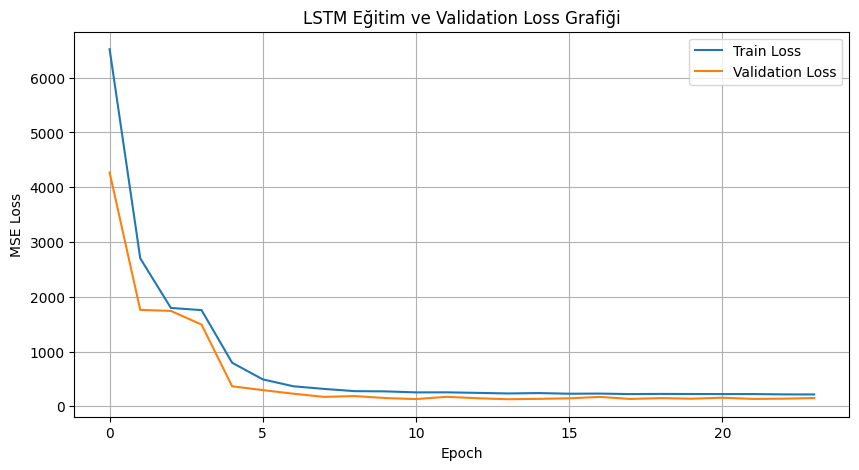

In [23]:
plt.figure(figsize=(10, 5))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("LSTM Eğitim ve Validation Loss Grafiği")
plt.legend()
plt.grid(True)
plt.show()

In [24]:
y_pred_lstm = lstm_model.predict(X_val_lstm).flatten()

mae_lstm = mean_absolute_error(y_val_lstm, y_pred_lstm)
rmse_lstm = np.sqrt(mean_squared_error(y_val_lstm, y_pred_lstm))
r2_lstm = r2_score(y_val_lstm, y_pred_lstm)

print("LSTM RUL Tahmini Performansı")
print("MAE:", mae_lstm)
print("RMSE:", rmse_lstm)
print("R2:", r2_lstm)

109/109 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step
LSTM RUL Tahmini Performansı
MAE: 7.99383544921875
RMSE: 11.422584355110248
R2: 0.9251033663749695


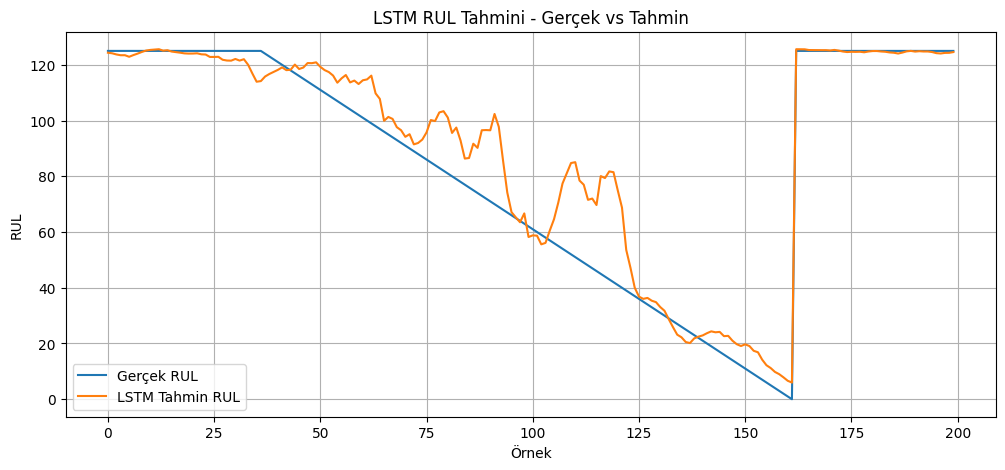

In [25]:
plt.figure(figsize=(12, 5))
plt.plot(y_val_lstm[:200], label="Gerçek RUL")
plt.plot(y_pred_lstm[:200], label="LSTM Tahmin RUL")
plt.xlabel("Örnek")
plt.ylabel("RUL")
plt.title("LSTM RUL Tahmini - Gerçek vs Tahmin")
plt.legend()
plt.grid(True)
plt.show()

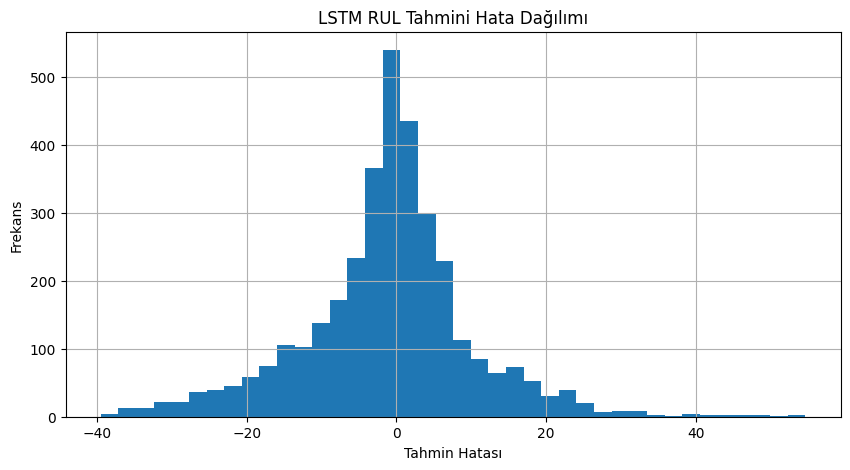

In [26]:
errors_lstm = y_val_lstm - y_pred_lstm

plt.figure(figsize=(10, 5))
plt.hist(errors_lstm, bins=40)
plt.xlabel("Tahmin Hatası")
plt.ylabel("Frekans")
plt.title("LSTM RUL Tahmini Hata Dağılımı")
plt.grid(True)
plt.show()

In [27]:
def create_test_sequences(test_data, feature_cols, window_size):
    X_test = []
    unit_numbers = []
    last_cycles = []

    for unit in test_data["unit_number"].unique():
        unit_data = test_data[test_data["unit_number"] == unit].sort_values("time_cycle")
        feature_values = unit_data[feature_cols].values

        if len(unit_data) >= window_size:
            sequence = feature_values[-window_size:]
        else:
            pad_size = window_size - len(unit_data)
            pad = np.repeat(feature_values[0:1], pad_size, axis=0)
            sequence = np.vstack([pad, feature_values])

        X_test.append(sequence)
        unit_numbers.append(unit)
        last_cycles.append(unit_data["time_cycle"].iloc[-1])

    return np.array(X_test), unit_numbers, last_cycles

In [28]:
X_test_lstm, test_units, test_last_cycles = create_test_sequences(
    test,
    feature_cols,
    WINDOW_SIZE
)

print("X_test_lstm shape:", X_test_lstm.shape)

X_test_lstm shape: (100, 30, 18)


In [29]:
test_rul_pred_lstm = lstm_model.predict(X_test_lstm).flatten()

lstm_test_results = pd.DataFrame({
    "unit_number": test_units,
    "time_cycle": test_last_cycles,
    "predicted_RUL_LSTM": test_rul_pred_lstm
})

lstm_test_results.head(20)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step


,unit_number,time_cycle,predicted_RUL_LSTM
0,1,0.083102,122.615051
1,2,0.132964,121.607704
2,3,0.346260,49.338093
3,4,0.290859,78.886139
4,5,0.268698,97.209801
5,6,0.288089,102.793175
6,7,0.440443,111.047821
7,8,0.457064,94.761925
8,9,0.149584,120.889458
9,10,0.529086,90.250053


In [30]:
def risk_from_rul(rul):
    if rul <= 30:
        return "Yüksek Risk"
    elif rul <= 60:
        return "Orta Risk"
    else:
        return "Düşük Risk"

lstm_test_results["risk_level"] = lstm_test_results["predicted_RUL_LSTM"].apply(risk_from_rul)

lstm_test_results.head(20)

,unit_number,time_cycle,predicted_RUL_LSTM,risk_level
0,1,0.083102,122.615051,Düşük Risk
1,2,0.132964,121.607704,Düşük Risk
2,3,0.346260,49.338093,Orta Risk
3,4,0.290859,78.886139,Düşük Risk
4,5,0.268698,97.209801,Düşük Risk
5,6,0.288089,102.793175,Düşük Risk
6,7,0.440443,111.047821,Düşük Risk
7,8,0.457064,94.761925,Düşük Risk
8,9,0.149584,120.889458,Düşük Risk
9,10,0.529086,90.250053,Düşük Risk


In [31]:
def maintenance_recommendation_from_rul(rul):
    if rul <= 30:
        return "Acil bakım planına alınmalı"
    elif rul <= 60:
        return "Yakından izlenmeli ve bakım planına dahil edilmeli"
    else:
        return "Normal izleme devam etmeli"

lstm_test_results["maintenance_recommendation"] = lstm_test_results["predicted_RUL_LSTM"].apply(
    maintenance_recommendation_from_rul
)

lstm_test_results.head(20)

,unit_number,time_cycle,predicted_RUL_LSTM,risk_level,maintenance_recommendation
0,1,0.083102,122.615051,Düşük Risk,Normal izleme devam etmeli
1,2,0.132964,121.607704,Düşük Risk,Normal izleme devam etmeli
2,3,0.346260,49.338093,Orta Risk,Yakından izlenmeli ve bakım planına dahil edil...
3,4,0.290859,78.886139,Düşük Risk,Normal izleme devam etmeli
4,5,0.268698,97.209801,Düşük Risk,Normal izleme devam etmeli
5,6,0.288089,102.793175,Düşük Risk,Normal izleme devam etmeli
6,7,0.440443,111.047821,Düşük Risk,Normal izleme devam etmeli
7,8,0.457064,94.761925,Düşük Risk,Normal izleme devam etmeli
8,9,0.149584,120.889458,Düşük Risk,Normal izleme devam etmeli
9,10,0.529086,90.250053,Düşük Risk,Normal izleme devam etmeli


In [32]:
top_10_lstm_risky = lstm_test_results.sort_values(by="predicted_RUL_LSTM").head(10)

top_10_lstm_risky

,unit_number,time_cycle,predicted_RUL_LSTM,risk_level,maintenance_recommendation
80,81,0.587258,8.116412,Yüksek Risk,Acil bakım planına alınmalı
34,35,0.545706,8.597593,Yüksek Risk,Acil bakım planına alınmalı
75,76,0.565097,9.420326,Yüksek Risk,Acil bakım planına alınmalı
67,68,0.515235,9.523177,Yüksek Risk,Acil bakım planına alınmalı
33,34,0.559557,9.784680,Yüksek Risk,Acil bakım planına alınmalı
81,82,0.445983,9.952385,Yüksek Risk,Acil bakım planına alınmalı
41,42,0.429363,10.199199,Yüksek Risk,Acil bakım planına alınmalı
30,31,0.540166,10.475711,Yüksek Risk,Acil bakım planına alınmalı
55,56,0.373961,14.384995,Yüksek Risk,Acil bakım planına alınmalı
19,20,0.506925,14.867326,Yüksek Risk,Acil bakım planına alınmalı


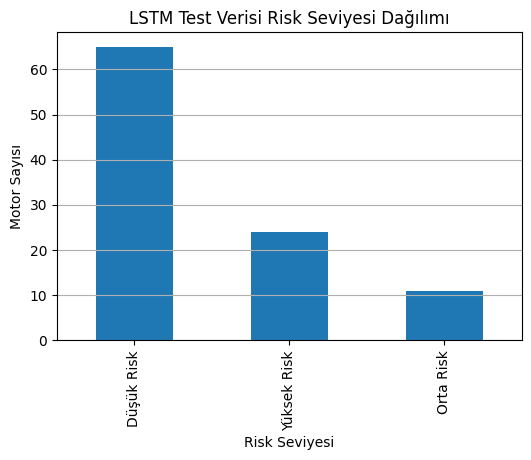

In [33]:
risk_counts_lstm = lstm_test_results["risk_level"].value_counts()

plt.figure(figsize=(6, 4))
risk_counts_lstm.plot(kind="bar")
plt.xlabel("Risk Seviyesi")
plt.ylabel("Motor Sayısı")
plt.title("LSTM Test Verisi Risk Seviyesi Dağılımı")
plt.grid(axis="y")
plt.show()

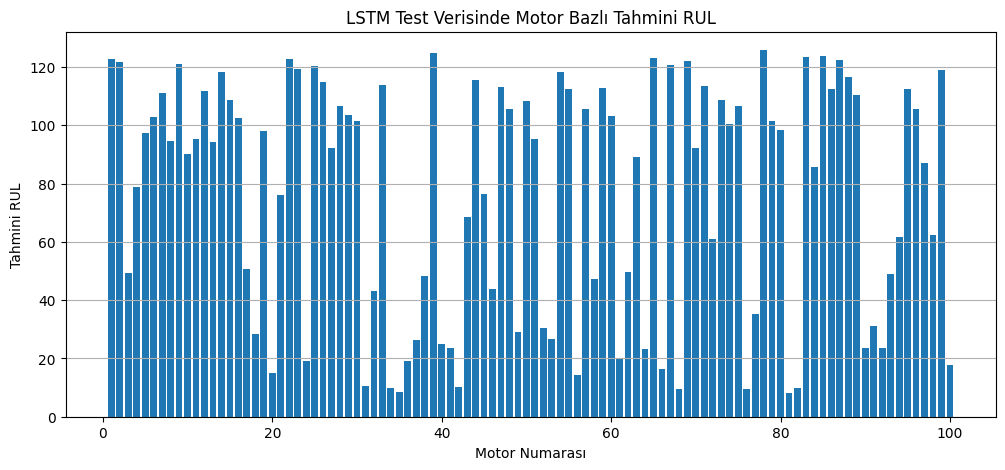

In [34]:
plt.figure(figsize=(12, 5))
plt.bar(lstm_test_results["unit_number"], lstm_test_results["predicted_RUL_LSTM"])
plt.xlabel("Motor Numarası")
plt.ylabel("Tahmini RUL")
plt.title("LSTM Test Verisinde Motor Bazlı Tahmini RUL")
plt.grid(axis="y")
plt.show()

In [35]:
lstm_test_results.to_excel("lstm_test_sonuclari.xlsx", index=False)

lstm_model_performance = pd.DataFrame({
    "Model": ["LSTM"],
    "Problem": ["RUL Tahmini"],
    "MAE": [mae_lstm],
    "RMSE": [rmse_lstm],
    "R2": [r2_lstm],
    "Window_Size": [WINDOW_SIZE],
    "RUL_CAP": [RUL_CAP]
})

lstm_model_performance.to_excel("lstm_model_performans_sonuclari.xlsx", index=False)

print("Excel dosyaları oluşturuldu.")

Excel dosyaları oluşturuldu.


In [36]:
lstm_model.save("lstm_rul_model.keras")

joblib.dump(scaler, "lstm_scaler.pkl")
joblib.dump(feature_cols, "lstm_feature_columns.pkl")

print("LSTM modeli ve yardımcı dosyalar kaydedildi.")

LSTM modeli ve yardımcı dosyalar kaydedildi.


In [37]:
from google.colab import files

files.download("lstm_test_sonuclari.xlsx")
files.download("lstm_model_performans_sonuclari.xlsx")
files.download("lstm_rul_model.keras")
files.download("lstm_scaler.pkl")
files.download("lstm_feature_columns.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [38]:
import zipfile
from google.colab import files

download_files = [
    "lstm_test_sonuclari.xlsx",
    "lstm_model_performans_sonuclari.xlsx",
    "lstm_rul_model.keras",
    "lstm_scaler.pkl",
    "lstm_feature_columns.pkl"
]

zip_name = "lstm_proje_ciktilari.zip"

with zipfile.ZipFile(zip_name, "w") as zipf:
    for file_name in download_files:
        if os.path.exists(file_name):
            zipf.write(file_name)

files.download(zip_name)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>